# Token and Embedding

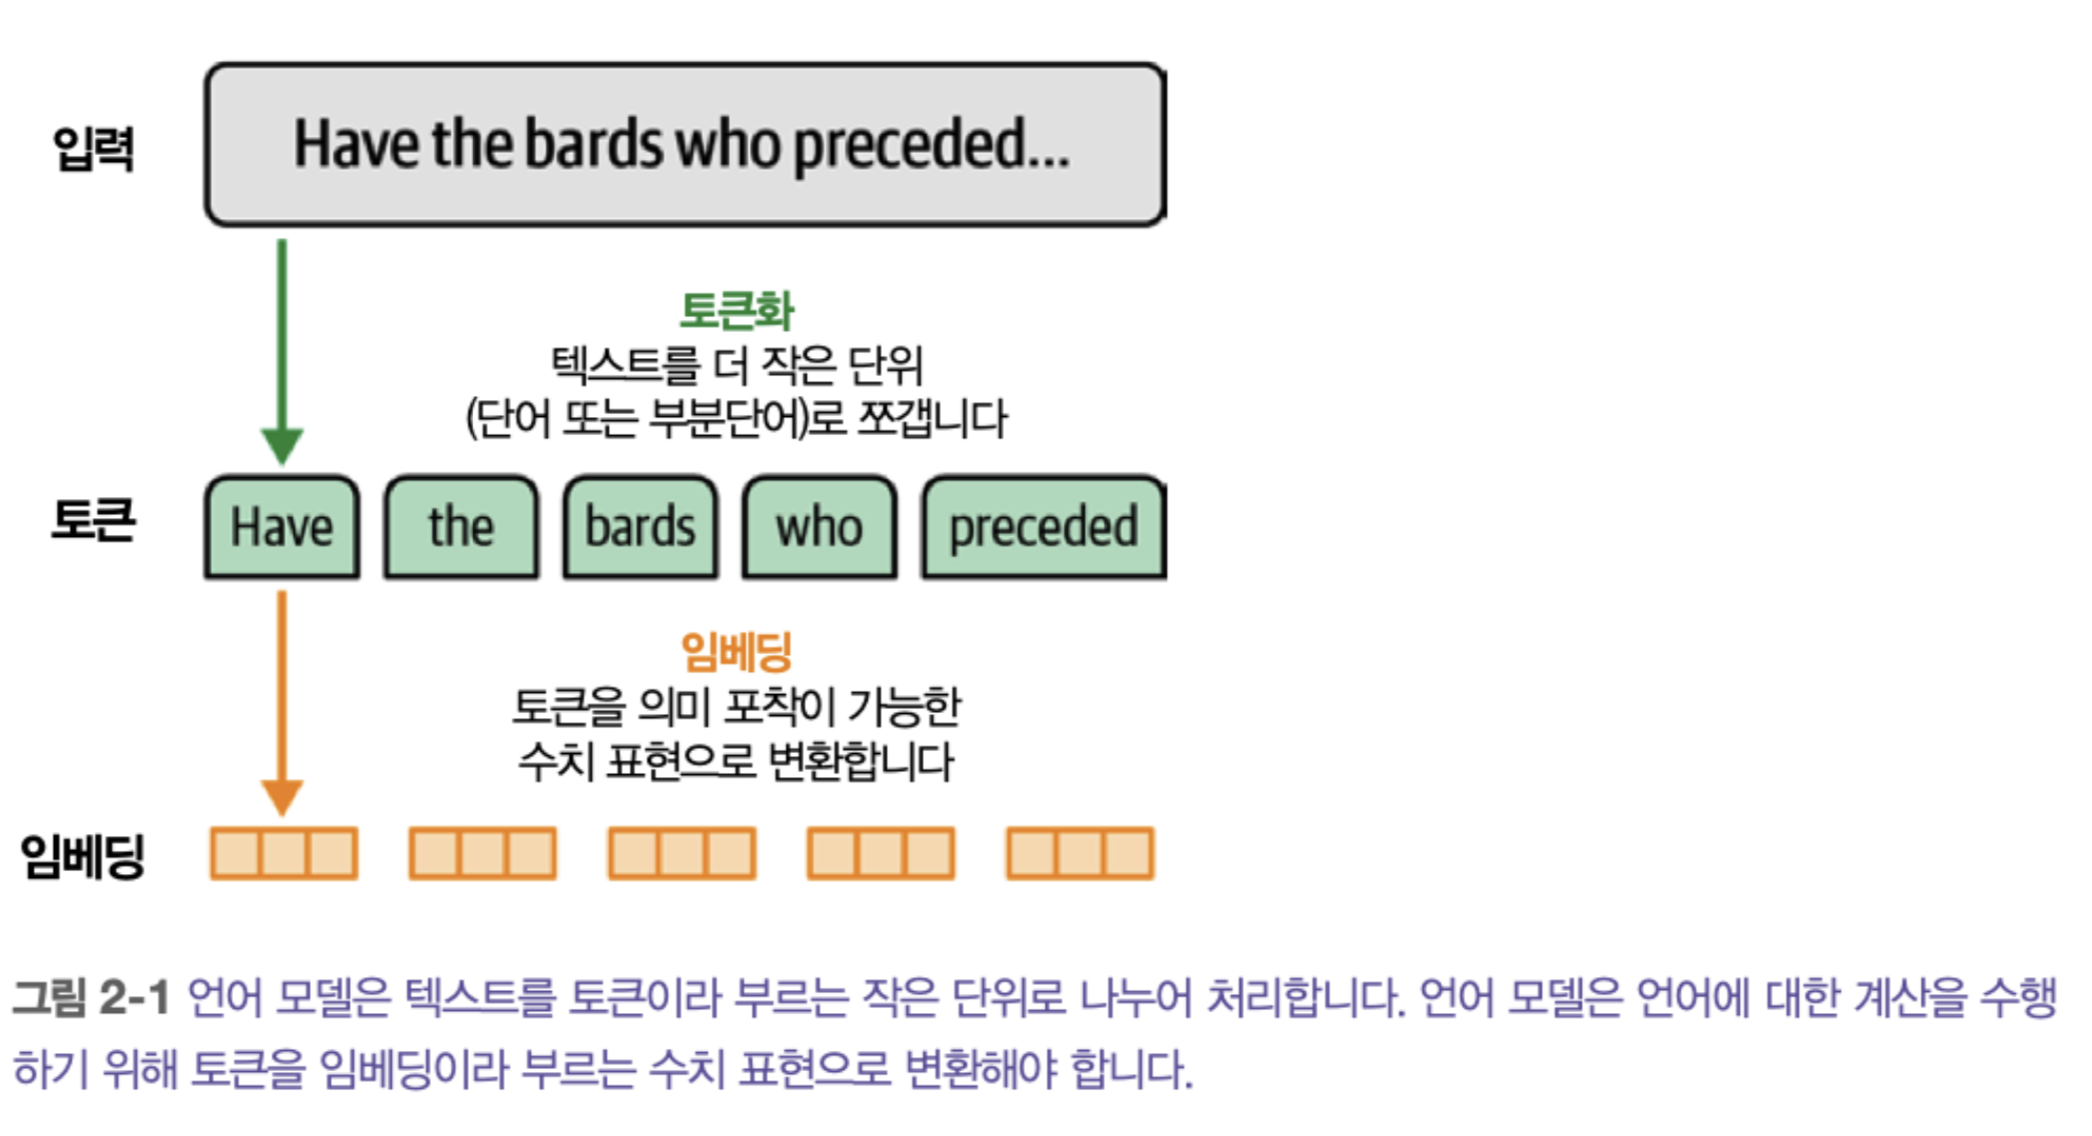

- LLM에서 쓰이는 Tokenization에 대해서 알아보자. 
- word2vec에 대해서 알아보자.
- 응용 사례(추천 시스템)에 적용해보자.

### 2.1 LLM Tokenization

- 모델이 한번에 모든 출력을 만들지 않고, 실제로 모델은 한 번에 하나의 토큰을 생성한다. 
- 하지만 토큰은 모델의 출력일 뿐만 아니라 모델이 입력을 보는 방법이기도 한다. 
- 먼저, 모델에 전달한 텍스트 프롬프트를 먼저 토큰으로 나누자. 

#### 2.1.1 토큰나이저가 언어 모델의 입력을 준비하는 방법
- 표면적으로는 생성형 LLM은 다음과 같이 입력 프롬프트를 받아 응답을 생성한다. 
    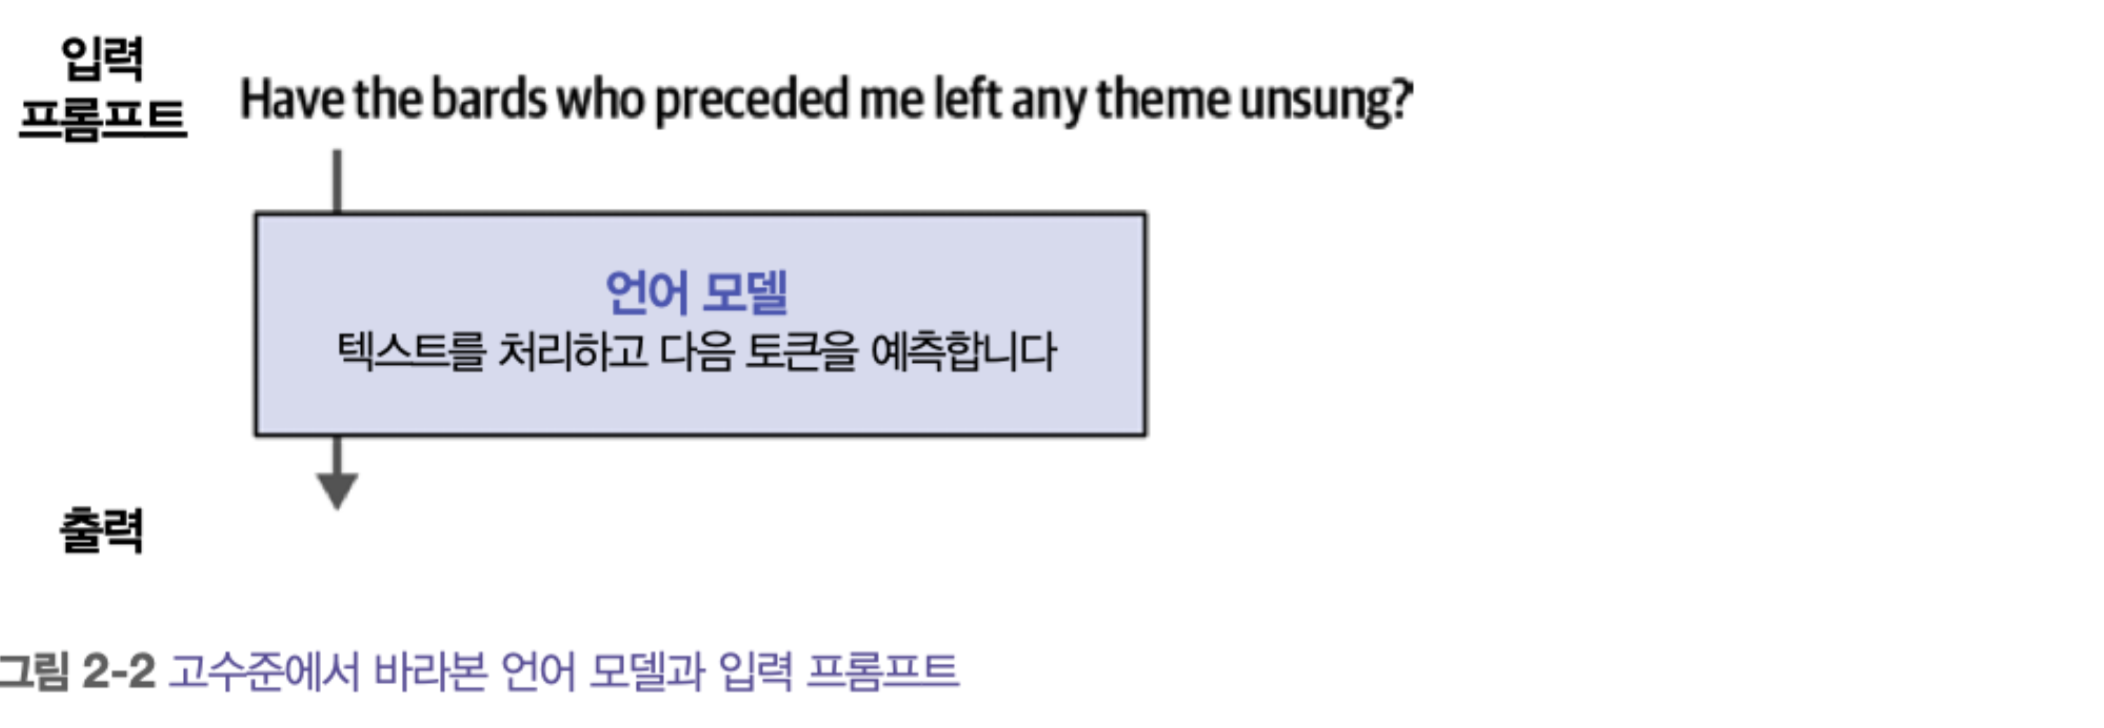
- 하지만 프롬프트를 언어 모델에 전달하기 전에 토크나이저에 통과시켜서 더 작은 단위로 쪼개야 한다. 
    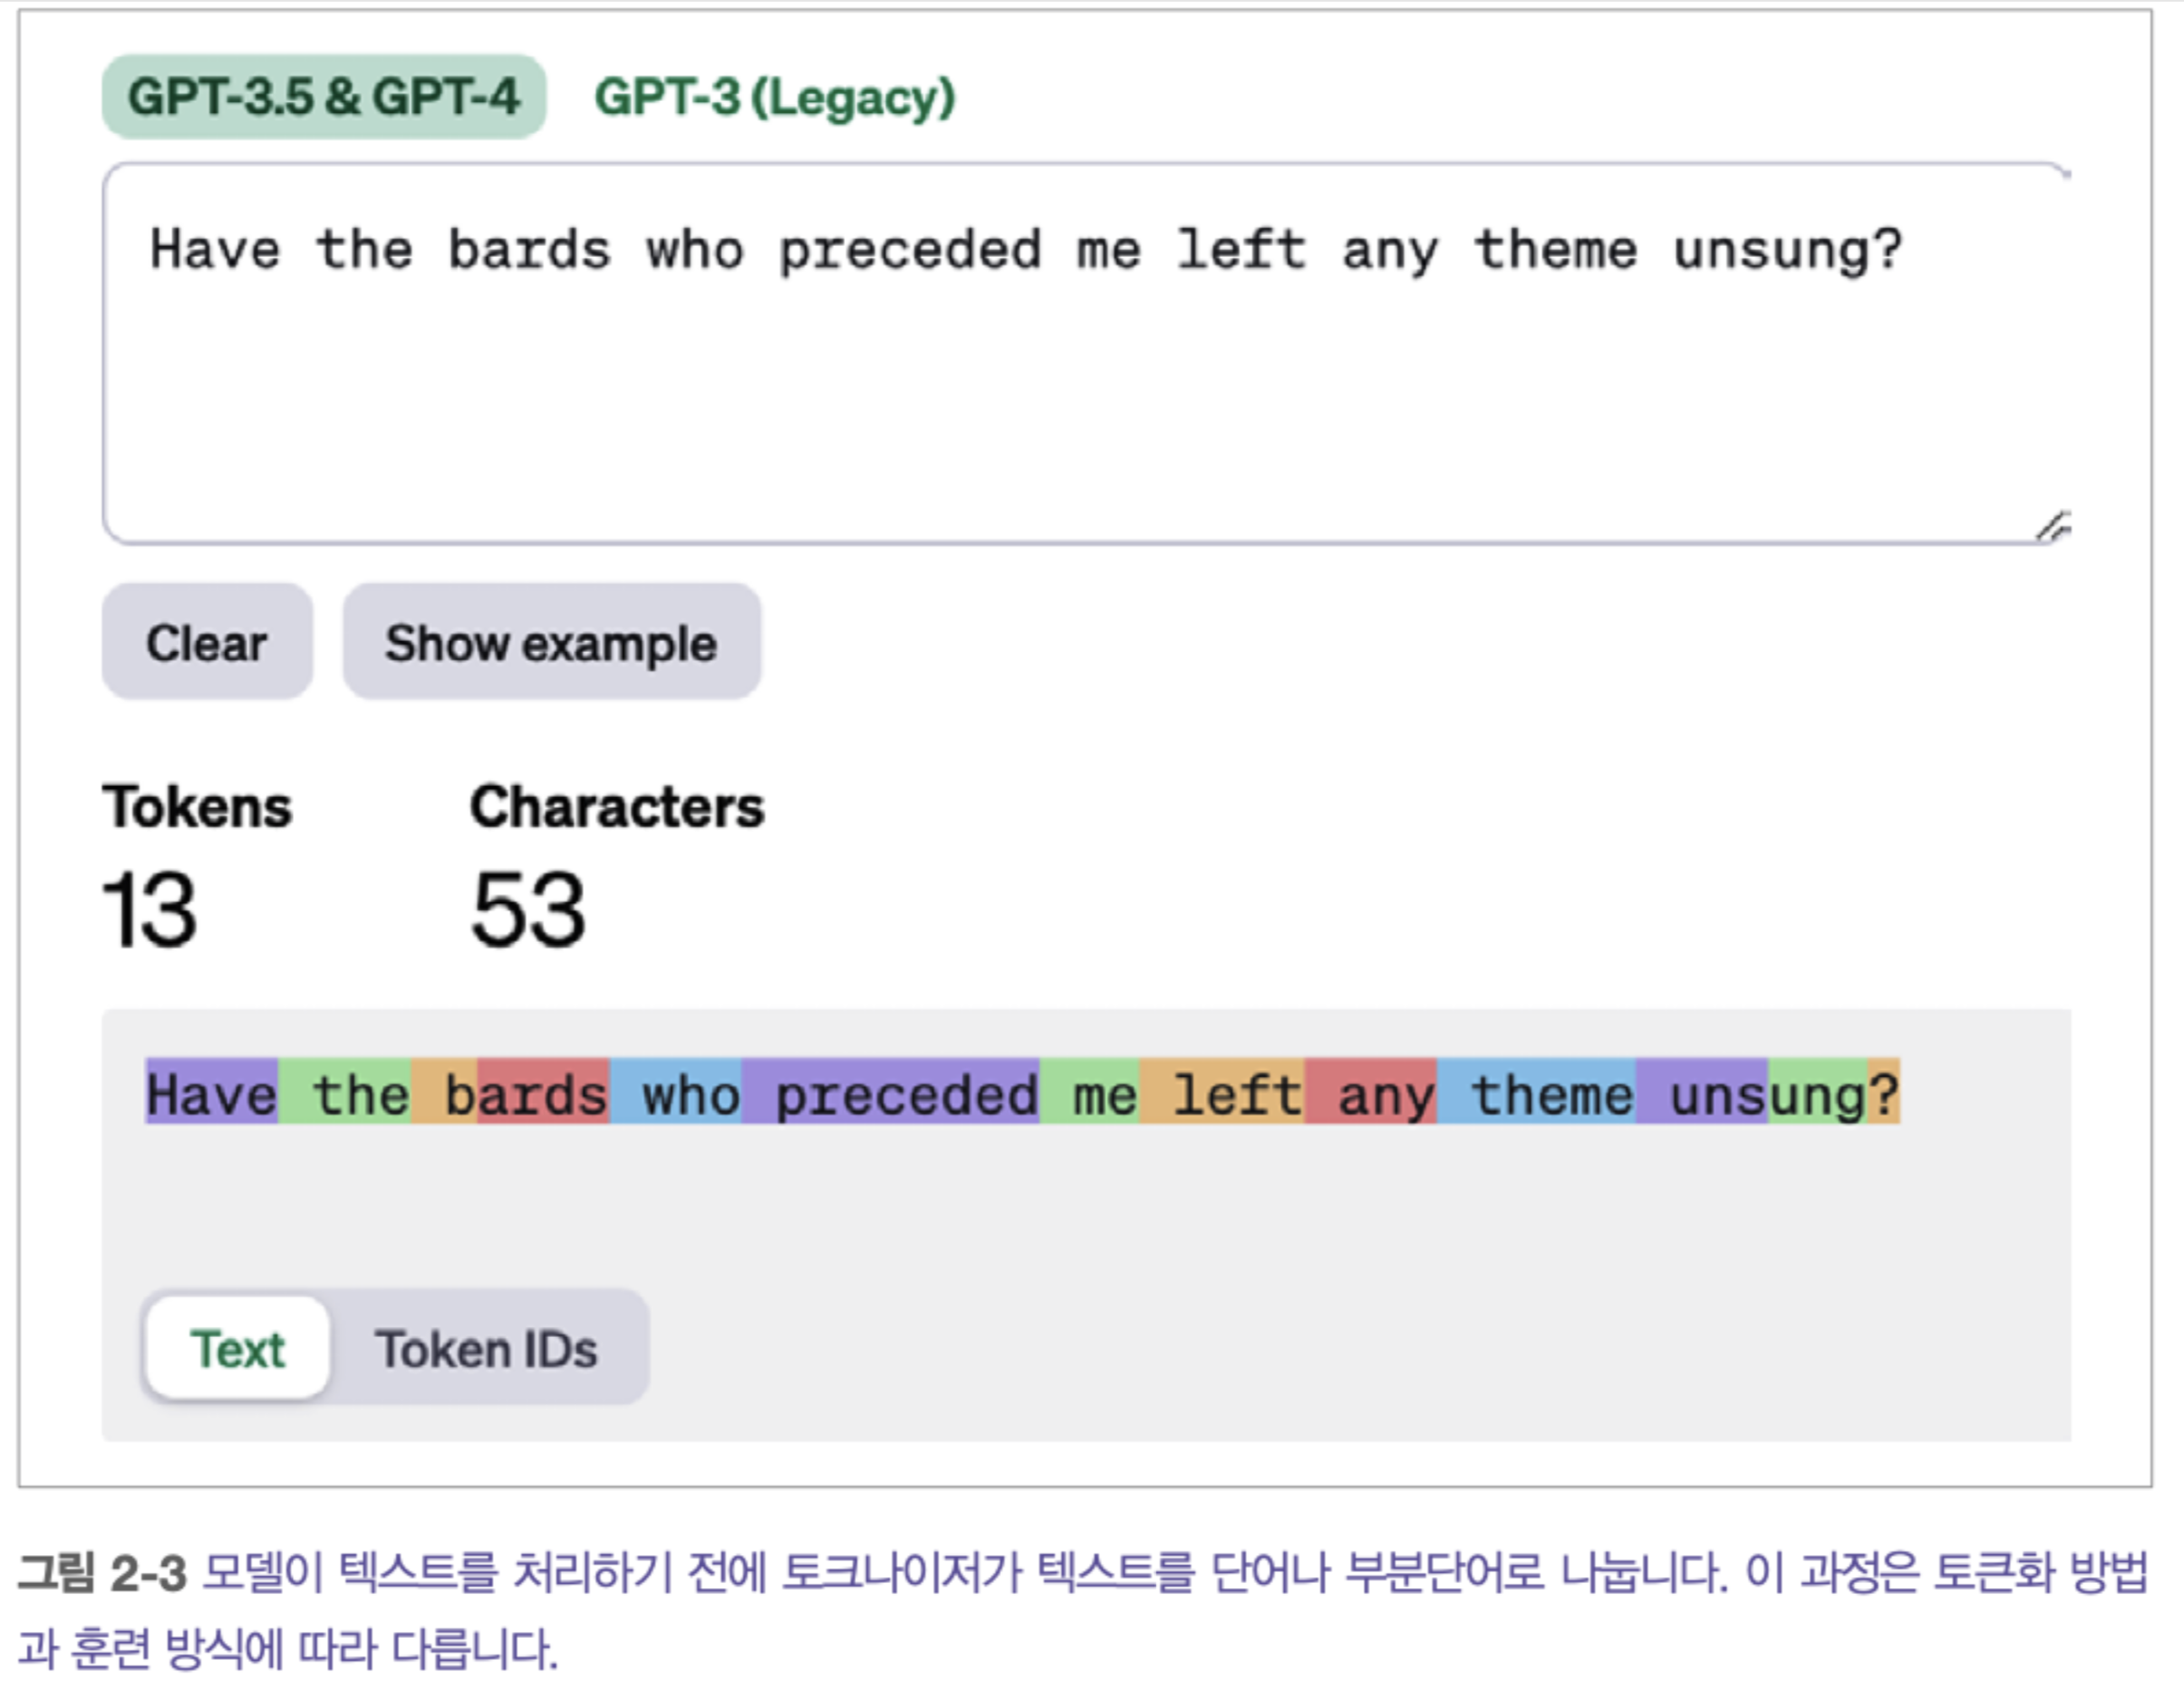

#### 2.1.2 LLM 다운로드하고 실행하기
- 샘플 코드를 사용해 토큰을 직접 다루어보자. 

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# 모델과 토크나이저를 로드합니다.
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    dtype="auto"
)
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/16.5k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

- 이제 실제 텍스트를 생성할 수 있다. 먼저 프롬프트를 준비하고, 토큰으로 분리해보자. 그 다음 토큰을 모델에 전달하여 출력을 생성한다. 
- 이번 예시에서는 모델에게 새로운 토큰 20개만 생성하도록 요창할 것이다. 

In [2]:
prompt = "Write an email apologizing to Sarah for the tragic gardening mishap. Explain how it happened.<|assistant|>"

# 입력 프롬프트를 토큰으로 나눕니다.
input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to("cuda")

# 텍스트를 생성합니다.
generation_output = model.generate(
  input_ids=input_ids,
  max_new_tokens=20
)

# 출력을 프린트합니다.
print(tokenizer.decode(generation_output[0]))

Write an email apologizing to Sarah for the tragic gardening mishap. Explain how it happened.<|assistant|> Subject: Heartfelt Apologies for the Gardening Mishap


Dear


In [3]:
print(input_ids)

tensor([[14350,   385,  4876, 27746,  5281,   304, 19235,   363,   278, 25305,
           293, 16423,   292,   286,   728,   481, 29889, 12027,  7420,   920,
           372,  9559, 29889, 32001]], device='cuda:0')


- 여기서 input_ids에는 integer들이 저장된 tensor로써 구성된다. 
- 출력을 보면 LLM이 받는 입력은 다음 그림과 같이 일련의 정수이다. 각 정수는 특정 토큰에 대한 고유한 ID이다. 이 ID는 토크나이저 내부에 있는 테이블에 대한 참조값이며, 이 테이블에는 토크나이저가 인식할 수 있는 모든 토큰이 담겨 있다. 
    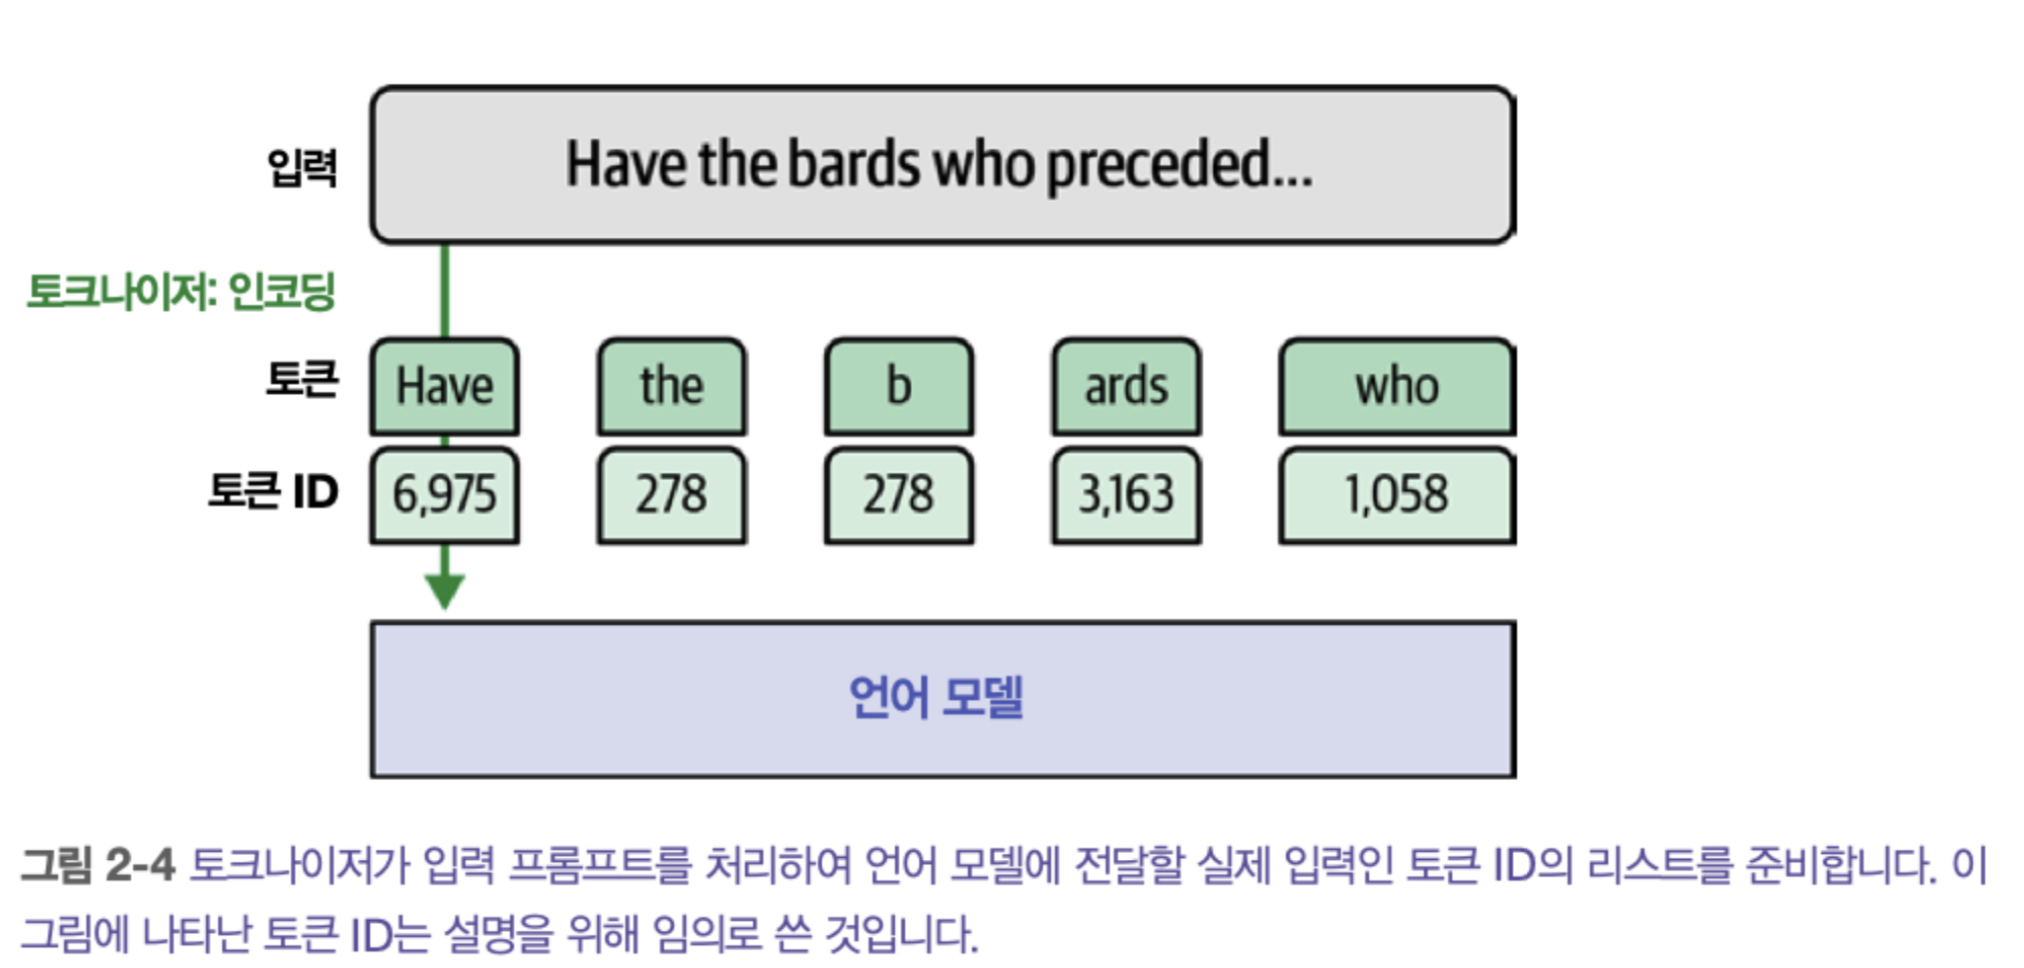

- 이 ID 값을 보려면 토크나이저의 decode 메서드를 사용해 ID를 텍스트로 변환할 수 있다 

In [4]:
for id in input_ids[0]:
   print(tokenizer.decode(id))

Write
an
email
apolog
izing
to
Sarah
for
the
trag
ic
garden
ing
m
ish
ap
.
Exp
lain
how
it
happened
.
<|assistant|>


토크나이저가 입력 프롬프트를 분할하는 방식이 이와 같다. 다음 사항을 유의하라. 
- 첫번째 토큰은 ID 1(<s>)이며, 텍스트의 시작을 나타내는 특수 토큰이다. 
- 일부 토큰은 완전한 단어이다.(e.g.: write, an, email)
- 일부 토큰은 부분단어이다.(e.g.: apologize, izing, trag, ic)
- 구두점 무낮도 하나의 토큰이다. 

공백 문자는 토큰으로 취급되지 않는다. 대신 부분 단어 토큰은 앞에 연결되는 토큰이 있는지를 나타내는 특별한 문자가 시작 부분에 숨겨져 있다. 

In [6]:
tokenizer(prompt).tokens()

['▁Write',
 '▁an',
 '▁email',
 '▁apolog',
 'izing',
 '▁to',
 '▁Sarah',
 '▁for',
 '▁the',
 '▁trag',
 'ic',
 '▁garden',
 'ing',
 '▁m',
 'ish',
 'ap',
 '.',
 '▁Exp',
 'lain',
 '▁how',
 '▁it',
 '▁happened',
 '.',
 '<|assistant|>']

출력 측면에서는 generation_output 변수 값을 출력하여 모델이 생성한 토큰을 조사할 수 있다. 

In [7]:
generation_output

tensor([[14350,   385,  4876, 27746,  5281,   304, 19235,   363,   278, 25305,
           293, 16423,   292,   286,   728,   481, 29889, 12027,  7420,   920,
           372,  9559, 29889, 32001,  3323,   622, 29901, 17778, 29888,  2152,
          6225, 11763,   363,   278, 19906,   292,   341,   728,   481,    13,
            13,    13, 29928,   799]], device='cuda:0')

모델은 토큰 ID 3323인 'Sub' 다음에 토큰 ID 622인 'ject'를 생성했다. 이 두 토큰을 합치면 단어 subject이 된다. 그 다음에 콜론(:)에 해당하는 토큰 ID 29901이 나오는 식이다. 입력과 마찬가지로 토크나이저의 decode 메서드를 사용해 생성된 토큰 ID를 실제 텍스트로 바꿀 수 있다. 이 메서드에 개별 토큰 ID나 토큰 ID의 리스트를 전달할 수 있다. 

In [8]:
print(tokenizer.decode(3323))
print(tokenizer.decode(622))
print(tokenizer.decode([3323, 622]))
print(tokenizer.decode(29901))

Sub
ject
Subject
:


#### 2.1.3 토크나이저가 텍스트를 분할하는 방법
토크나이저가 입력 프롬프트를 나누는 방법을 결정하는 주요 요소는 세 가지이다. 
1. 모델 설계 시에 모델 작성자가 토큰화 방법을 선택한다: BPE(Byte Pair Encoding), WordPiece(BERT) 
   - 텍스트 데이터셋을 표현하는 토큰 집합을 최적화한다는 점에서 비슷하지만, 목표에 도달하는 방식이 다름
2. 토큰화 방법을 선택한 후에 어휘 사전 크기와 특수 토큰 같은 토크나이저 설계상의 여러가지 선택을 해야함(2.1.5 참조)
3. 토크나이저는 특정 데이터셋에서 훈련하여 해당 데이터셋을 표현하는 최상의 어휘사전을 구축해야한다. 
   - 동일한 방법과 파라미터를 사용하더라도 영어 텍스트 데이터셋에서 훈련된 토크나이저는 코드 데이터셋이나 다국어 텍스트 데이터셋에서 훈련된 토크나이저와 다름. 
토크나이저는 언어 모델을 위해 입력 텍스트를 처리하는 외에도 아래에서 보듯이 언어 모델의 출력 결과에 생성된 토큰 ID를 해당하는 단어나 토큰으로 변환하기도 한다. 
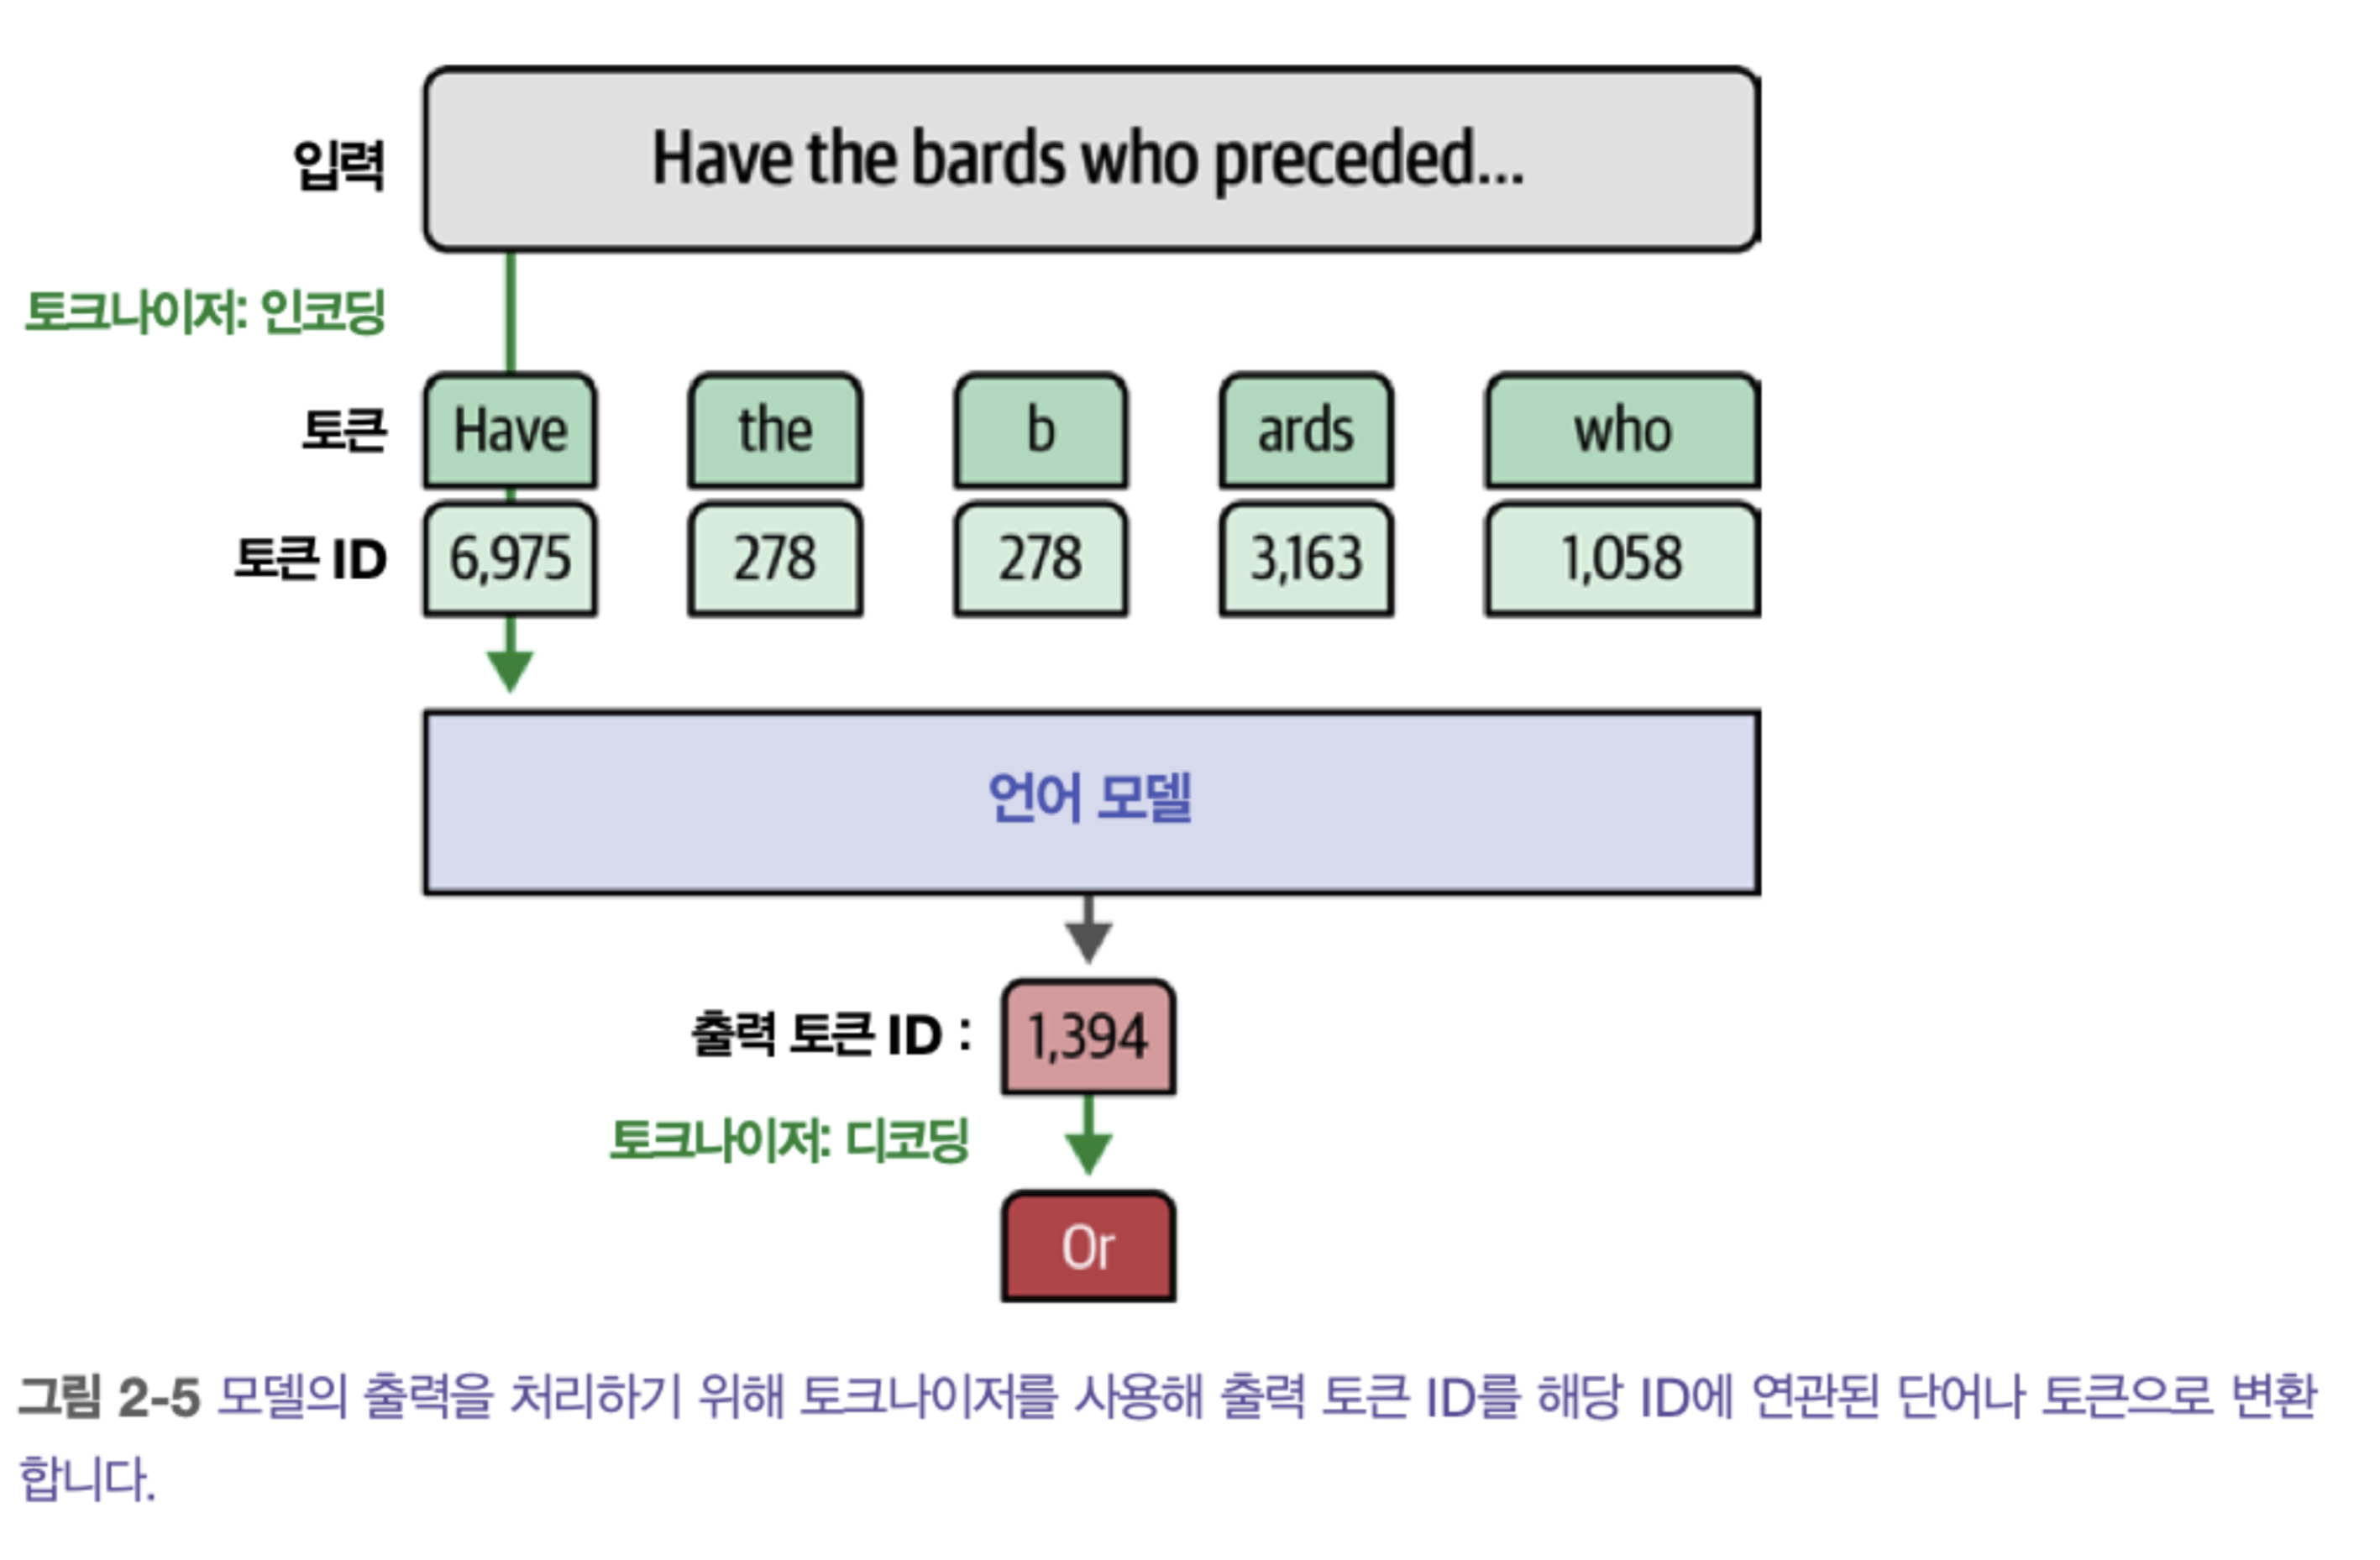

#### 2.1.4 단어 토큰, 부분단어 토큰, 문자 토큰, 바이트 토큰
방금 소개한 토큰화 방법을 부분단어 토큰화(subword tokenization)이라고 한다. 유일하지는 않지만, 가장 널리 ㅏㅅ용되는 토큰화이다. 아래에 4가지 주요 토큰화 방법에 대한 도식이 있다. 

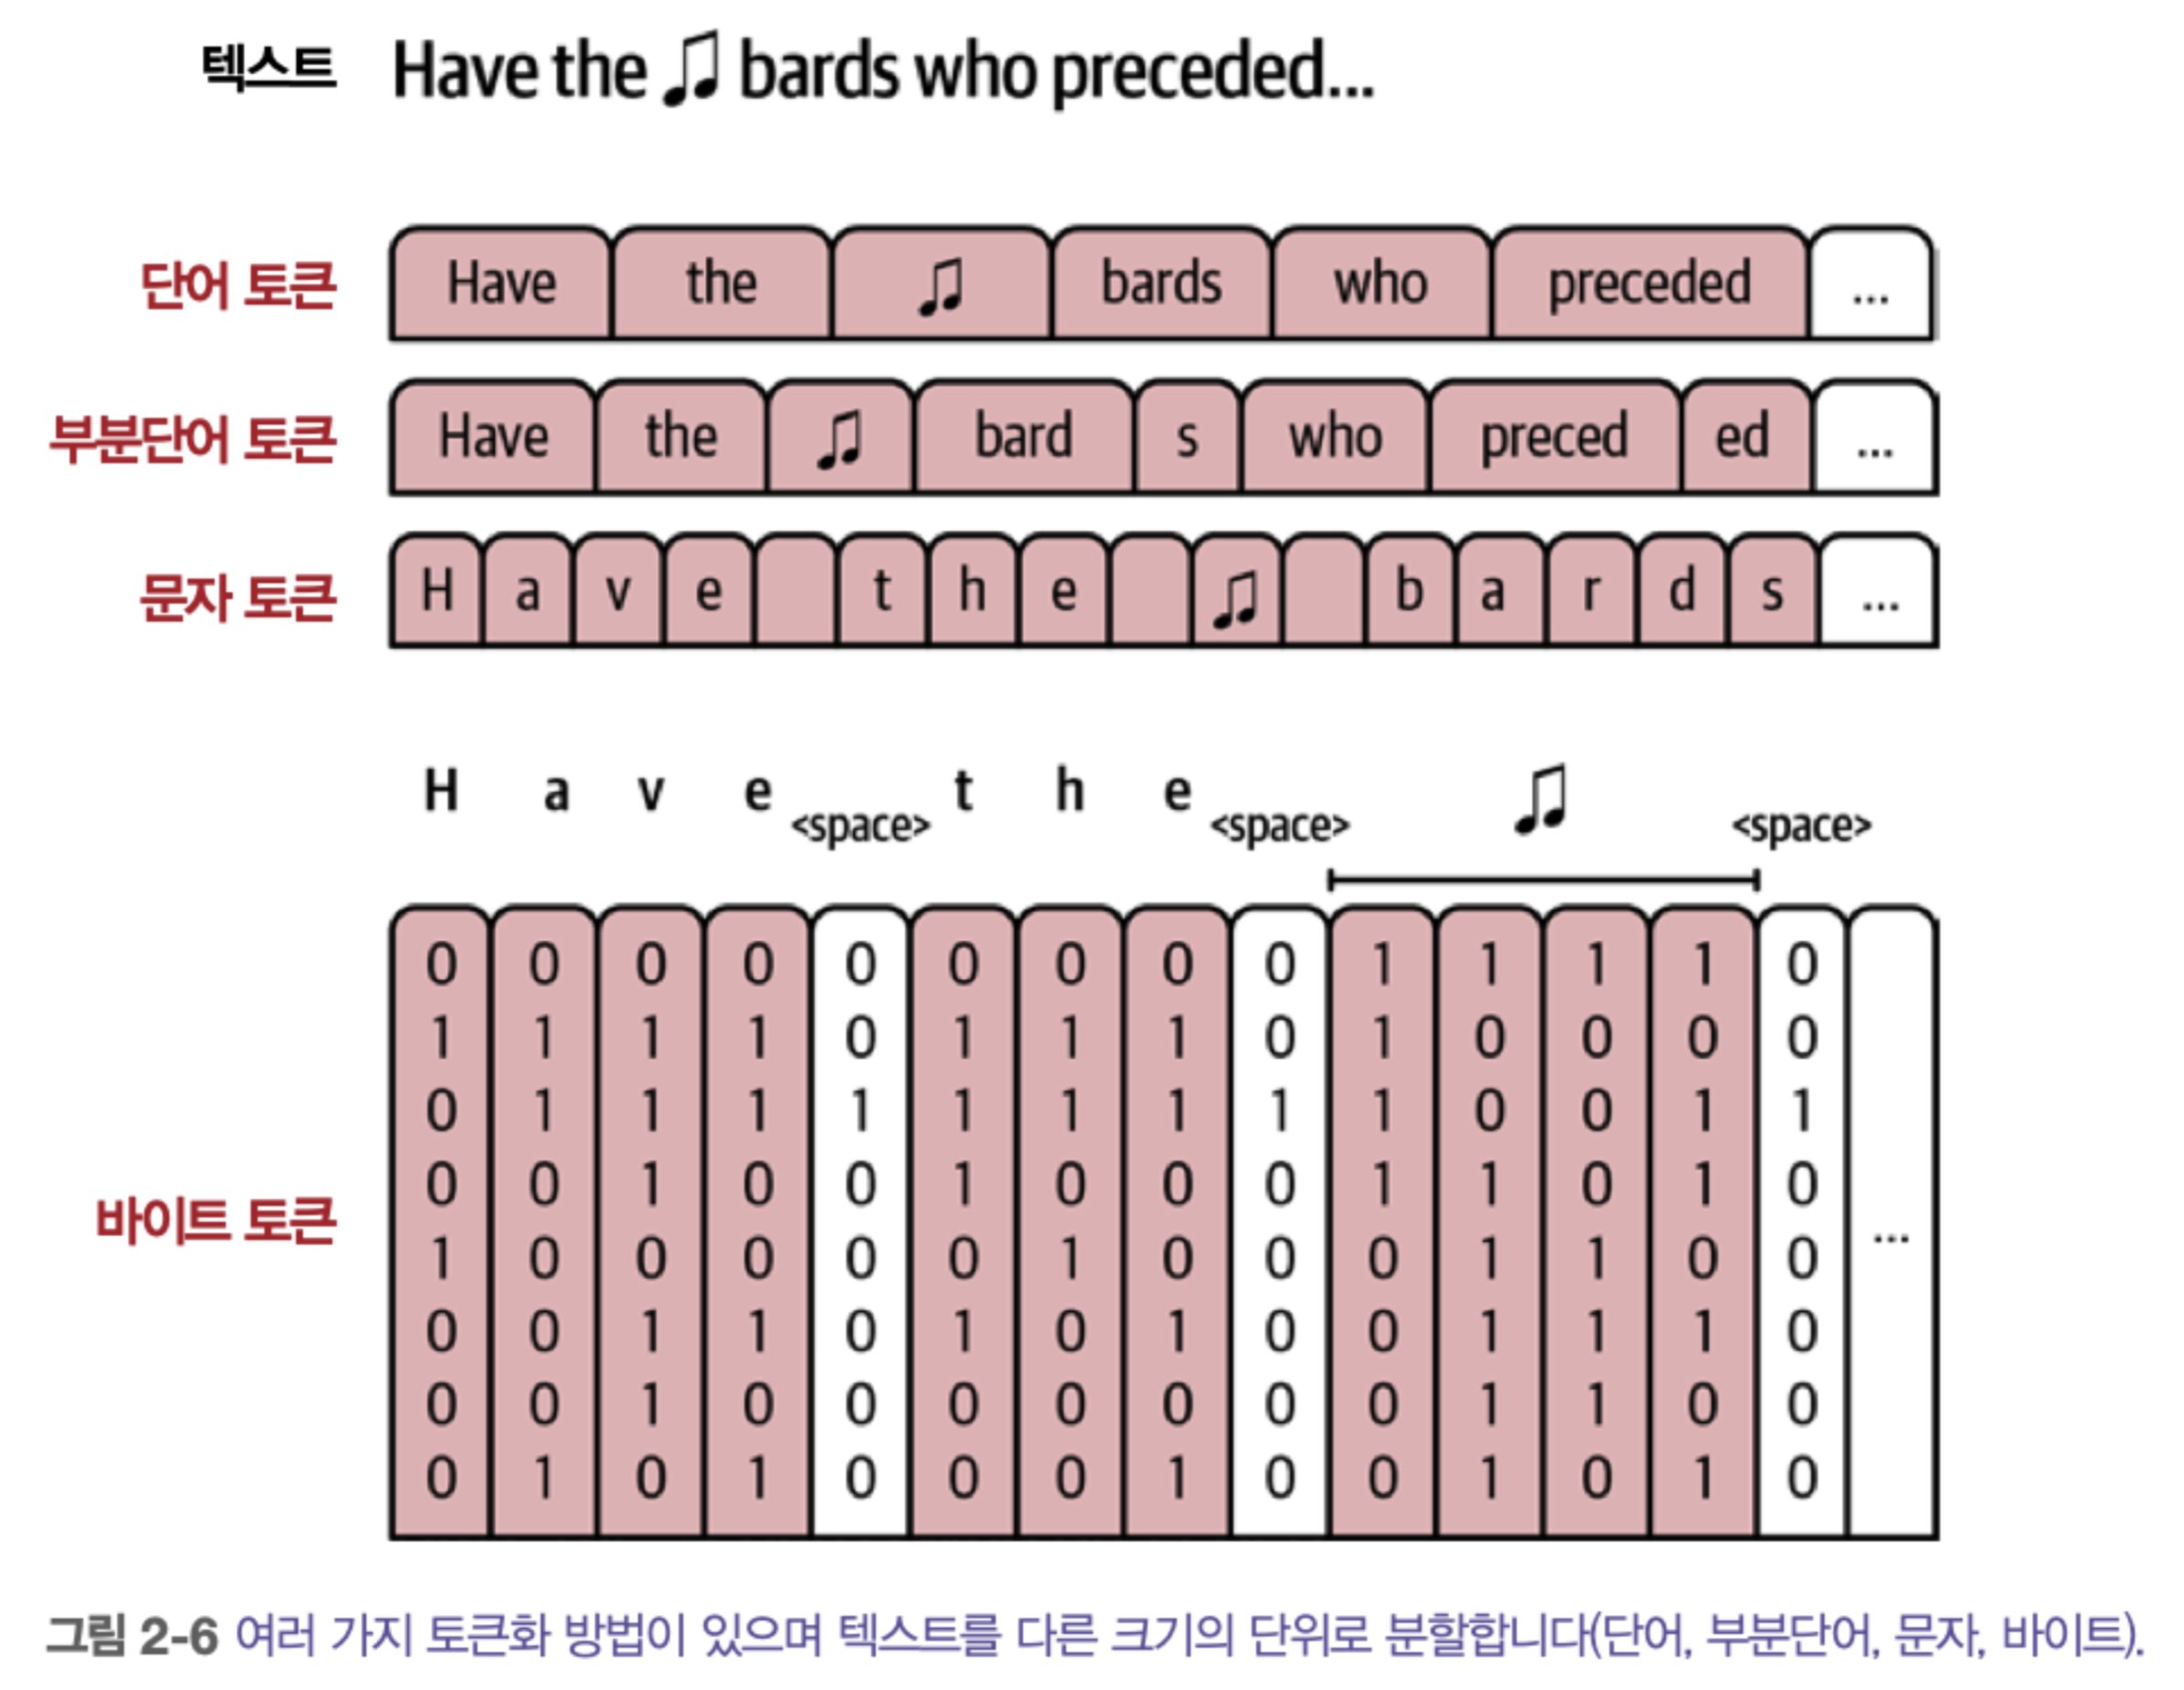

##### 1. 단어 토큰
- 이 방법은 word2vec같은 초기 토큰화에 보편적으로 사용되었으나, NLP에서는 점점 덜 사용된다. 
- 주로 추천 시스템에서 사용된다. 
- 단어 토큰화의 한 가지 문제는 토크나이저가 훈련된 후에 데이터셋에 새롭게 추가된 "단어"를 처리할 수 없다는 것이다. 이로 인해 차이가 크지 않은 비슷한 토큰을 어휘사전이 많이 가지고 있어야 한다(apology, apologize, apoloetic, apologist) 
- 이 문제는 부분단어 토큰화를 통해 apolog 토큰과 다른 토큰에 공통으로 사용되는 접미사 토큰으로 나누어 해결할 수 있다. 결과적으로 표현력이 더 좋은 어휘사전을 만들 수 있게 된다. 

##### 2. 부분단어 토큰
- 이 방법은 완전한 단어와 부분단어를 포함한다. 앞서 언급한 어휘 사전의 표현력 외에 또 다른 장점은 새로운 단어를 (어휘 사전에 포함되어 있을 가능성이 높은) 더 작은 단위로 나누기 때문에 새로운 단어도 표현할 수 있다. 
  
##### 3. 문자 토큰
- 대체할 원시 문자가 있기 때문에 새로운 단어를 잘 처리할 수 있는 또 다른 방법이다. 
- 토큰화 표현이 쉽지만 모델링은 어렵다. 부분단어 토큰화 모델이 'play'를 하나의 토큰으로 표현하지만, 문자 수준 토큰화를 사용하는 모델은 나머지 시퀀스를 모델링하는 것 외에도 'p-l-a-y'를 조합하는 정보까지 모델링해야 한다. 
- 트랜스포머 모델은 문맥 길이가 제한되어 있기 때문에 부분 단어 토큰이 문자 토큰에 비해 더 많은 텍스트를 처리할 수 있는 이점이 있다. 문맥 길이가 1,024인 모델의 경우 문자 토큰화보다 부분단어 토큰화를 사용하면 약 세 배 더 많은 텍스트를 처리할 수 있다. 

##### 4. 바이트 토큰
- 유니코드 문자를 표현하는 바이트로 토큰을 분할하는 또 다른 토큰화 방법이다.(https://arxiv.org/pdf/2103.06874), tokenization-free encoding'이라고 부르는 방법을 소개한다. 
- 다국화 환경에서 이러한 바이트 토큰이 경쟁력이 았다(https://arxiv.org/pdf/2105.13626)

#### 2.1.5 훈련된 LLM 토크나이저 비교하기
토크나이저가 토큰을 나타내는 방법을 결정하는 주요 세 가지 요소는 (1) 토큰화 방법, (2) 토크나이저 초기화 파라미터와 특수 토큰, (3) 토크나이저가 훈련하는 데이터셋 이다. 훈련된 여러 토크나이저를 비교해보면서 이런 선택이 어떻게 토크나이저의 동작을 바꾸는지 알아보자. 이렇게 비교해보면 새로운 토크나이저가 모델 성능을 개선하기 위해 동작 방식을 바꾸었다는것을 알 수 있다. 또한 특수한 모델은 종종 특수한 토크나이저가 필요하다는 것도 알게 될 것이다. 

In [10]:
text = """
English and CAPITALIZATION
🎵 鸟
show_tokens False None elif == >= else: two tabs:"		" four spaces:"    "
12.0*50=600
"""

- 이 텍스트를 사용하면 토크나이저마다 여러 다른 종류의 토큰을 어떻게 처리하는지 알 수 있다. (대문자/영어 외이 단어/이모지/들여씨기를 위한 공백과 키워드가 있는 프로그래밍코드/숫자와 자리수/특수토큰;시작과 끝 또는 다른 기능 등)
- 오래된 토크나이저부터 새로운 토크나이저 순으로 앞의 텍스트를 어떻게 토큰화하는지와 그것이 언어 모델에 대해 무엇을 알려주는지 살펴보자. 
- 텍스트를 토큰화한 다음 아래 함수를 사용해 각 토큰에 배경색을 넣어서 출력하자. 

In [19]:
from transformers import AutoModelForCausalLM, AutoTokenizer

colors_list = [
    '102;194;165', '252;141;98', '141;160;203',
    '231;138;195', '166;216;84', '255;217;47'
]

def show_tokens(sentence, tokenizer_name):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    token_ids = tokenizer(sentence).input_ids
    for idx, t in enumerate(token_ids):
        # 텍스트를 인코딩한 후 다시 디코딩했을 때 원본 텍스트와 동일해지려면
        # clean_up_tokenization_spaces를 False로 지정해야 합니다.
        # 현재 이 매개변수의 기본값은 None(True에 해당)이며
        # transformers 4.45에서 True로 바뀔 예정입니다.
        # https://github.com/huggingface/transformers/issues/31884
        print(
            f'\x1b[0;30;48;2;{colors_list[idx % len(colors_list)]}m' +
            tokenizer.decode(t, clean_up_tokenization_spaces=False) +
            '\x1b[0m',
            end=' '
        )


from transformers import AutoTokenizer
from IPython.display import HTML, display
from html import escape

def show_tokens(sentence, tokenizer_name):
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
    token_ids = tokenizer(sentence).input_ids
    colors = ["#66c2a5", "#fc8d62", "#8da0cb",
              "#e78ac3", "#a6d854", "#ffd92f"]

    spans = []
    for i, token_id in enumerate(token_ids):
        text = tokenizer.decode(
            [token_id], clean_up_tokenization_spaces=False
        )
        spans.append(
            f'<span style="background-color:{colors[i % len(colors)]};'
            f'color:#111">{escape(text)}</span>'
        )

    display(HTML(
        '<div style="white-space:pre-wrap;font-family:monospace;'
        'tab-size:4;line-height:1.8">'
        + "".join(spans) + "</div>"
    ))

| 모델 | 연도 | 토큰화 방법 | 어휘사전 크기 | 주요 특수 토큰 및 역할 |
|---|---:|---|---:|---|
| **BERT base (uncased)** | 2018 | WordPiece | 30,522 | `[UNK]`: 알 수 없는 토큰<br>`[SEP]`: 텍스트 구분<br>`[PAD]`: 길이 맞춤<br>`[CLS]`: 분류<br>`[MASK]`: 예측 대상 가리기 |
| **BERT base (cased)** | 2018 | WordPiece | 28,996 | uncased와 동일한 특수 토큰 사용. 대소문자를 구분함 |
| **GPT-2** | 2019 | BPE | 50,257 | `<\|endoftext\|>`: 텍스트 끝 |
| **Flan-T5** | 2022 | SentencePiece | 32,100 | `<unk>`: 알 수 없는 토큰 |
| **GPT-4** | 2023 | BPE | 100,000개 초과 | `<\|endoftext\|>`: 텍스트 끝<br>`<\|fim_prefix\|>`, `<\|fim_middle\|>`, `<\|fim_suffix\|>`: 중간 채우기 영역 구분 |
| **StarCoder2** | 2024 | BPE | 49,152 | `<\|endoftext\|>`: 텍스트 끝<br>`<fim_prefix>`, `<fim_middle>`, `<fim_suffix>`, `<fim_pad>`: 코드 중간 채우기<br>`<filename>`, `<reponame>`, `<gh_stars>`: 파일·저장소 메타데이터 |
| **Galactica** | — | BPE | 50,000 | `<s>`, `</s>`: 시작·끝<br>`<pad>`, `<unk>`: 패딩·알 수 없는 토큰<br>`[START_REF]`, `[END_REF]`: 인용 영역<br>`<work>`: 단계별 추론 |
| **Phi-3** | — | BPE | 32,000 + 추가 특수 토큰 | Llama 2 토크나이저 재사용<br>`<\|endoftext\|>`: 텍스트 끝<br>`<\|user\|>`, `<\|assistant\|>`, `<\|system\|>`: 대화 역할 구분 |

##### BERT 베이스 모델(uncased), 2018

In [20]:
show_tokens(text, "bert-base-uncased")

- BERT는 두 가지 형태로 출시됨(대문자가 유지되는 cased와 모든 대문자를 소문자로 바꾼 uncased), uncased가 더 인기가 많음. 
- uncased에 대해서 다음을 확인할 수 있음: 
  - 줄 바꿈 문자가 사라져서 모델이 줄바꿈에 인코딩된 정보를 알지 못함
  - 모든 텍스트가 소문자임
  - 단어 'capitalization'아 두 개의 subtoken으로 인코딩됨. ## 문자는 이 토큰이 앞에 있는 토큰의 부분 토큰임을 나타냄. 또한 공백 위치를 나타내는 방법임. **즉 ## 문자가 없는 토큰 앞에는 공백이 있다고 가정함.**
  - 이모지와 한자는 'unknown token'을 의미하는 [unk] 특수 토큰으로 대체됨 

##### BRT 베이스 모델(cased), 2018

In [21]:
show_tokens(text, "bert-base-cased")

- cased 버전의 BERT 토크나이저는 주로 대문자 토큰이 있다는 점이 다름
- CAPITALIZATION이 여덟개의 토큰으로 표햔됨. 
- 두 버전의 BERT 토크나이저는 [CLS] 시작 토큰과 [SEP] 종료 토큰으로 입력을 감쌈. 각가은 입력 텍스트를 감싸기 위한 유틸리티 토큰이며 토큰 자체의 고유한 목적도 가지고 있음. 
  - 전자는 문장 분류를 위해 사용되는 분류 토큰임
  - 후자는 모델에 두 개의 문장을 전달해야하는 일부 어플리케이션에서 문장을 구분하기 위해 사용함.

##### GPT-2, 2019

In [22]:
show_tokens(text, "gpt2")

- 줄바꿈이 토크나이저 내에서 표현됨
- 대문자가 유지되고, capitalization은 4개의 토큰으로 표현됨
- 이모지와 한자는 각각 여러개의 토큰으로 표햔됨. 출력은 � 로 됐지만, 실제로는 각자 다른 토큰임. 예를 들어 이모지는 ID가 8582, 236, 113인 토큰으로 나누어짐. 이 토큰나이저는 세 토큰을 원래 문자로 재구성할 수 있음. 예를 들어, tokenizer.decode([8582, 236, 113])를 실행하면 이모지가 출려됨
- 두 개의 탭은(어휘사전에서 토큰 번호 197) 두 개의 토큰으로 표현됨. 세개의 탭은 세 개의 토큰(번호 220)으로 표현되며 마지막 공백은 닫는 따옴표 문자를 위한 토큰의 일부가 됨

##### Flan-T5, 2022

In [23]:
show_tokens(text, "google/flan-t5-small")

- Flan-T5 모델 패밀리는 SentencePiece를 사용함. 여기서 다음과 같은 내용을 알 수 있음: 
- 줄바꿈이나 공백 토큰이 없기에 모델이 코드를 다루기가 어려움(파이썬)
- 이모지와 한자가 모두 <unk> 토큰으로 바뀌었기에 모델이 식별할 수 없음

##### GPT-4, 2023

In [24]:
# 공식 토크나이저는 `tiktoken`이지만 허깅 페이스 플랫폼에 동일한 토크나이저가 있습니다.
show_tokens(text, "Xenova/gpt-4")

- GPT-2 토크나이저와 비슷하게 동작하나 몇 가지 차이점이 존재: 
- GPT-4 토크나이저는 네 개의 공백을 하나의 토큰으로 표현. 길이가 93인 공백시퀀스까지 하나의 토큰으로 나타냄. 실제로는 82개의 연속된 공백은 두 개의 토큰으로 나뉨. 또한 83개보다 긴 공백 중에 87, 91, 95, 128개의 연속된 공백은 하나의 토큰으로 인코딩
- 파이썬 키워드 elif 는 GPT-4에서 하나의 토큰으로 표현됨. 앞의 항목과 함께 이는 모델이 자연어 외에 코드에 초점을 맞추고 있다는 것을 나타냄
- GPT-4는 더 적은 토큰을 사용해 대부분의 단어를 표현함. 예를 들어 'CAPITALIZATION'은 네 개가 ㅏㅇ니라 두 개의 토큰으로 나뉨. 'tokens'는 세 개가 아니라 한 개의 토큰으로 표현됨. 

##### StarCoder2, 2024

In [25]:
show_tokens(text, "bigcode/starcoder2-15b")

- 코드 생성에 맞춘 디코더임. 
- GPT-4와 비슷하게 여러 개의 공백을 하나의 토큰으로 인코딩
- 지금까지 본 모델과의 차이는 각각의 숫자가 하나의 토큰으로 할당됨(600 -> 6 0 0). 아마도 숫자와 수학을 더 잘 표현할 ㅜㅅ 있을것이라고 기대됨. 한 예로, GPT-2는 숫자 870을 하나의 토큰으로 표현하지만, 871은 두 개의 토큰 8과 71으로 표현함. 모델이 숫자를 표현하는데 혼란이 일어날 수도 있음

##### Galactica

In [26]:
show_tokens(text, "facebook/galactica-1.3b")

- https://arxiv.org/pdf/2211.09085
- 과학 지식에 맞추어 많은 과학 논문, 참조 자료, 지식 데이터에서 훈련됨. 특별히 토큰화에 더 주위를 기울여 데이터셋에 있는 늬앙스에 민감함. 
- StarCodeer2와 비슷하게 동작함. 공백을 동일한 방식으로 인코딩함. 즉, 길이가 다른 고앱ㄱ 리스트를 하나의 토큰에 할당함. 하지만 StarCoder2와 달리 탭도 하나의 토큰으로 인코딩함. (지금까지 본 모든 토크나이저 중에 두 개의 탭으로 구성된 문자열 '\t\t'를 하나의 토큰에 할당하는 유일한 토크나이저)

##### Phi-3(그리고 LLama 2)

In [27]:
show_tokens(text, "microsoft/Phi-3-mini-4k-instruct")

#### 2.1.6 토크나이저 속성
앞선 사례를 통해 사전 훈련된 토크나이저를 살펴보면서 한 토크나이저가 다른 토크나이저와 차별화되는 점을 알아보았다. 토크나이저가 텍스트를 분할하는 방법을 결정하는 설계상의 선택을 크게 세 가지로 나눌 수 있다
1. 토큰화 방법
2. 초기화 파라미터
3. 토크나이저가 목표로 하는 도메인
   
##### 토큰화 방법
- BPE가 가장 인가가 높다
- 각각의 방법은 데이터셋을 표현하기 위해 적절한 토큰 집합을 선택하는 알고리즘에 대한 것
- https://huggingface.co/docs/transformers/tokenizer_summary 참조


##### 토크나이저 파라미터
- 토큰화 방법을 선택한 후, LLM 설계자는 토크나이저 파라미터를 결정해야 한다. 이를 위해 다음과 같은 것들이 포험된다 
- **어휘 사전 크기** 토크나이저 어휘 사전에 얼마나 많은 토큰을 포함할 것인지. (30k, 50k 또는 100k의 어휘 사전)
- **특수 토큰** 모델이 추적해야 할 특수 토큰은 무엇인가? 특수한 목적으로 LLM을 만드는 경우라면 원하는 만큼 이를 추가할 수 있다. 일반적으로는 텍스트 시작 토큰(<s>), 텍스트 종료 토큰, 패딩 토큰, Unknown 토큰, CLS 토큰, 마스킹 토큰 등이 포함된다. 이외에도 LLM 설계자는 현재 다루려는 문제 도메인을 잘 모델링 할 수 있는 토큰을 추가할 수 있다. 
- **대소문자** 영어와 같은 언어에서 대소문자를 어떻게 다루어야 하나? 대소문자는 종종 유용한 정보를 제공하지만 단어의 대문자 버전을 위해 어휘 사전 공간을 낭비해야만하나?


##### 데이터의 도메인
- 동일한 방법과 파라미터를 선택했더라도 토크나이저의 동작은 훈련한 데이터셋에 따라 달라진다. 앞서 언급한 토큰화 방법은 특정 데이터셋을 표현하기 위해 어휘사전을 최적화한다. 훈련된 토크나이저를 살펴보며 코드와 다국어 ㅌ텍스트 같은 데이터셋에서 어떤 영향으 받는지 앞서 확인해 보았다. 
- 예를 들어 코드의 경우 텍스트에 초점을 맞춘 토크나이저는 들여쓰기 공백을 모두 토큰화할 수 있다. 
    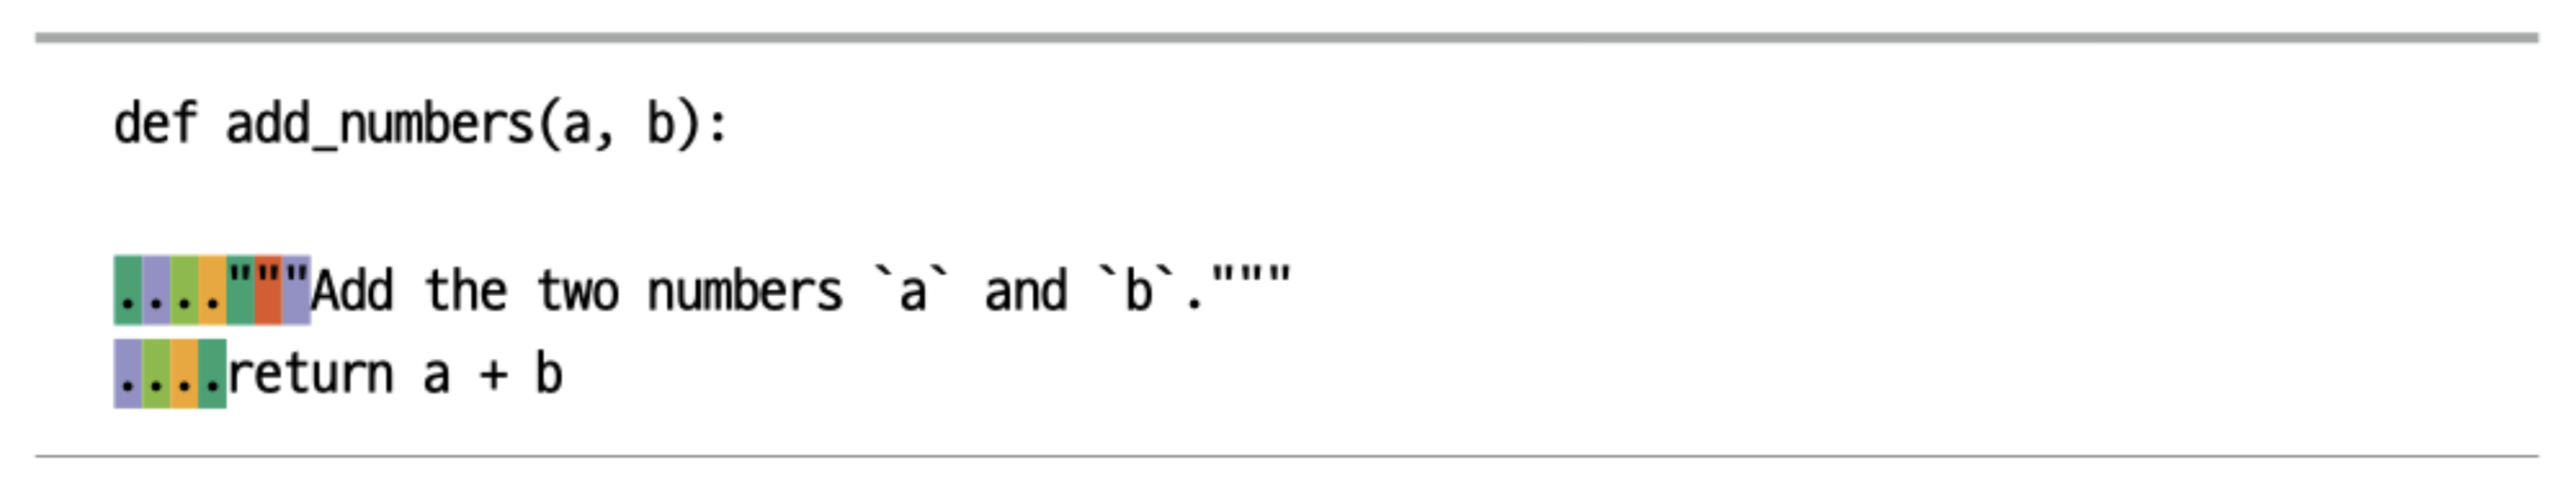
- 이 방법이 코드에 초점을 맞춘 모델에게는 최적이 아닐 수 있다. 코드 중심 모델은 종종 다른 토큰화 방법을 사용하여 이를 개선할 수 있다. 
    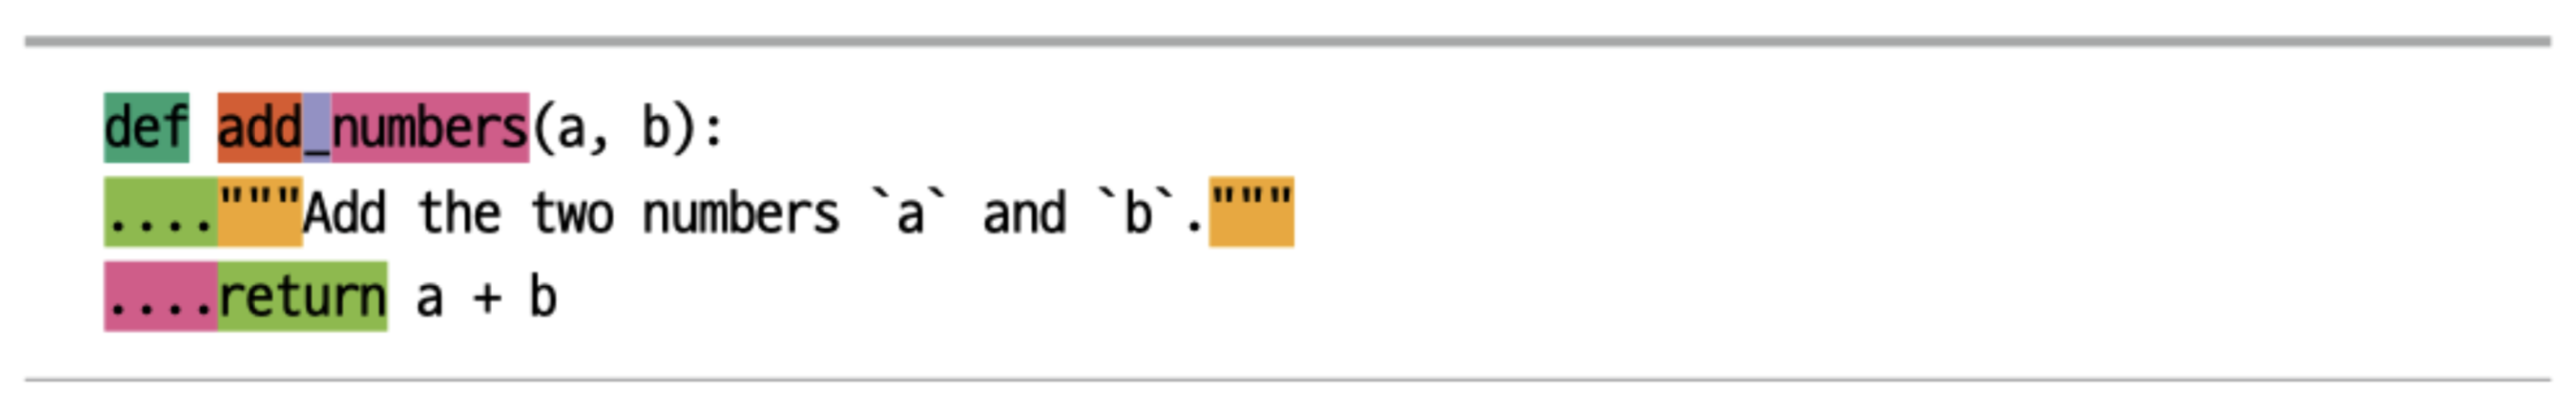
- 이런 토큰화 방법 선택은 모델의 작업을 쉽게 만들어 주며 모델이 성능이 향상될 가능성을 높여준다. 

### 2.2 Token Embedding

### 2.3 Text Embedding(sentence and whole document)

### 2.4 Word Embedding

### 2.5 Embedding for recomendation systems